In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import roc_auc_score
from tensorflow.keras.layers import Dense, Activation, BatchNormalization, LSTM, Masking, Input, GRU, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from tensorflow.keras import regularizers
from sklearn.utils import shuffle
from qkeras import *
import qkeras
from tensorflow.keras.models import load_model
from qkeras.utils import model_quantize
from qkeras.utils import model_save_quantized_weights

2025-11-01 20:12:22.446639: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-01 20:12:23.607102: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-01 20:12:29.276219: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-01 20:12:29.276311: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-01 20:12:30.575712: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
from sklearn.model_selection import train_test_split

### GRU

In [67]:
def grumodel(max_len, n_var, rec_units, ndense=[50, 10], l1_reg=0,
              l2_reg=0, rec_act='sigmoid', extra_lab='none', rec_kernel_init='VarianceScaling',
             dense_kernel_init='lecun_uniform'):
    
    hidden = x_in = Input(shape=(max_len, n_var,))
    hidden = GRU(units=rec_units,
                  recurrent_activation = rec_act,
                  kernel_initializer = rec_kernel_init, 
                  name = 'gru')(hidden)
    
    hidden = Dense(50, kernel_initializer=dense_kernel_init, name='dense_0' )(hidden)
    hidden = Activation('relu', name = 'relu_0')(hidden)
    
    hidden = Dense(10, kernel_initializer=dense_kernel_init, name='dense_1' )(hidden)
    hidden = Activation('relu', name = 'relu_1')(hidden)

    hidden = Dense(3, kernel_initializer=dense_kernel_init, name = 'dense_2')(hidden)
    hidden = Activation('softmax', name = 'output_softmax')(hidden)
    
    model = Model(inputs=x_in, outputs=hidden)
    
    return model

### LSTM

In [68]:
def lstmmodel(max_len, n_var, rec_units, ndense=[10], l1_reg=0,
              l2_reg=0, rec_act='sigmoid', extra_lab='none', rec_kernel_init='VarianceScaling',
             dense_kernel_init='lecun_uniform', domask=False):
    
    hidden = x_in = Input(shape=(max_len, n_var,))
    hidden = LSTM(units=rec_units,
                  recurrent_activation = rec_act,
                  kernel_initializer = rec_kernel_init, 
                  name = 'lstm1')(hidden)
    hidden = Dense(50, kernel_initializer=dense_kernel_init, name='dense_0' )(hidden)
    hidden = Activation('relu', name = 'relu_0')(hidden)
    hidden = Dense(10, kernel_initializer=dense_kernel_init, name='dense_1' )(hidden)
    hidden = Activation('relu', name = 'relu_1')(hidden)
    hidden = Dense(3, kernel_initializer=dense_kernel_init, name='dense_2' )(hidden)
    hidden = Activation('softmax', name='output_softmax')(hidden)
    model = Model(inputs=x_in, outputs=hidden)
    
    return model

## Floating Point Model Training

In [69]:
l1_reg = 0
l2_reg = 0

## GRU Model
model = grumodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)

## LSTM Model
#model = lstmmodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)

model.compile(optimizer='adam', loss=['categorical_crossentropy'], metrics=['accuracy'])
    
model_output = 'gru_test3/gru_weights.h5'

train = False
if train:
    history = model.fit(x_train, y_train,
            batch_size=2**10,
            epochs=150,
            validation_data=(x_val, y_val), 
            shuffle = True,
            sample_weight= w_train,
            callbacks = [
                EarlyStopping(verbose=True, patience=20, monitor='val_accuracy'),
                ModelCheckpoint(model_output, monitor='val_accuracy', verbose=True, save_best_only=True)
                ],
            verbose=True
            )
#y_keras = model.predict(x_test, batch_size=2**10)
#auc_score = roc_auc_score(y_test, y_keras)
#print("AUC score:", auc_score)

## GRU weight

In [70]:
model = load_model("./gru_test3/gru_weights.h5", custom_objects={'QGRU': QGRU, 'QDense': QDense, 'quantized_bits': quantized_bits, 'QActivation': QActivation})

for layer in model.layers:
    weights = layer.get_weights()
    print(layer.name, weights)

input_1 []
gru [array([[-0.12469812, -0.28928995,  0.24783108, ...,  0.09020978,
         1.3361043 ,  0.2131291 ],
       [ 0.1327692 , -0.08152957,  0.25204852, ...,  0.08305766,
        -0.40952712, -0.08306952],
       [-0.03643114,  0.05480863, -0.37831095, ...,  0.08108549,
        -0.20789394,  0.2881709 ],
       [-0.3405804 , -0.132991  , -0.21851636, ..., -0.02375418,
         0.45972824,  0.17867932],
       [-0.5600249 ,  0.20899312, -0.61330974, ...,  0.16689596,
        -0.23248236, -0.6929572 ],
       [-0.2772438 , -0.26483715,  0.39346495, ...,  0.03653004,
        -0.3099163 ,  0.32959458]], dtype=float32), array([[-0.00120384,  0.02518557,  0.11613223, ...,  0.00860514,
        -0.17399853, -0.09032135],
       [ 0.1389099 , -0.01724965,  0.21604231, ...,  0.02770575,
        -0.20152883,  0.09281268],
       [ 0.22167127,  0.25377536, -0.02039688, ..., -0.06135429,
        -0.1431508 ,  0.08396748],
       ...,
       [-0.00848735, -0.08626914, -0.09164452, ...,  0.

## LSTM weight

In [71]:
model = load_model("lstm_test2/lstm_weights.h5")

for layer in model.layers:
    weights = layer.get_weights()
    print(layer.name, weights)

input_6 []
lstm1 [array([[ 0.49079454, -1.1204377 , -0.05260832, ...,  0.16984597,
        -0.20320961, -0.08185341],
       [ 0.38426185, -0.808004  , -0.15241025, ...,  0.07156762,
         0.59442973,  0.05756089],
       [ 0.04227524, -0.9423642 ,  0.88680595, ...,  1.1980453 ,
         0.3316359 ,  0.3752381 ],
       [ 0.00435796, -0.10688871,  0.36524487, ...,  0.6310424 ,
        -0.24402067,  0.48337543],
       [ 0.34662625,  0.23644   ,  0.91399103, ..., -0.06033983,
         0.66045   , -0.29554167],
       [ 0.81278235,  0.18537585, -0.30137703, ..., -0.6476805 ,
        -0.16395459, -0.6595477 ]], dtype=float32), array([[-0.1512722 ,  0.16262484, -0.22720727, ..., -0.08130786,
        -0.17788623, -0.2520775 ],
       [ 0.09537277, -0.08669291,  0.30998278, ...,  0.1758767 ,
        -0.29684278, -0.07141834],
       [ 0.09804206, -0.01613149,  0.08990317, ...,  0.00711243,
        -0.04714818,  0.1428612 ],
       ...,
       [ 0.03762303, -0.08936564, -0.14454861, ...,  

## Quantization Aware Training

## QGRU

In [72]:
from qkeras.utils import model_quantize

l1_reg = 0
l2_reg = 0

## GRU Model
model = grumodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)

## LSTM Model
#model = lstmmodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)
# new_GRU_0int = []
# new_GRU_1int = []
# new_GRU_4int = []
# GRU_1int = []
for int_bits in [0]:
    for i in [1]:
        total_bits = i + int_bits + 1

        config = {
            "QGRU":{
                "kernel_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
                 "bias_quantizer" : f"quantized_bits({total_bits}, {int_bits},1)",
                 "recurrent_quantizer": f"quantized_bits({total_bits},{int_bits},1)",
                 "state_quantizer" : f"quantized_bits({total_bits},{int_bits},1)"
            },
            "QDense":{
                "kernel_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
                "bias_quantizer" : f"quantized_bits({total_bits},{int_bits},1)"
            },
            "relu_0" : f"quantized_relu({total_bits},{int_bits},1)",
            "relu_1" : f"quantized_relu({total_bits},{int_bits},1)",
        }
    
        qmodel = model_quantize(model, config, total_bits, transfer_weights=True)
    
# for layer in qmodel.layers:
#         if hasattr(layer, "recurrent_quantizer"):
#             print(layer.name, "kernel:", str(layer.kernel_quantizer_internal), "bias:", str(layer.bias_quantizer_internal), 
#                     "recurrent:", str(layer.recurrent_quantizer_internal), "state:", str(layer.state_quantizer_internal))
#         elif hasattr(layer, "kernel_quantizer"):
#             print(layer.name, "kernel:", str(layer.kernel_quantizer_internal), "bias:", str(layer.bias_quantizer_internal))
#         elif hasattr(layer, "quantized_relu"):
#             print(layer.name, "quantized_relu:", str(layer.quantizer))
#         else:
#             print(layer.name)
                
        qmodel.summary()
    
        qmodel.compile(optimizer='adam', loss=['categorical_crossentropy'], metrics=['accuracy'])
    
        model_output = f'{int_bits}int_qgru_test3/{i}frac_qgru_weights.h5'
    
        train = False
        if train:
            history = qmodel.fit(x_train, y_train,
                    batch_size=2**14,
                    epochs=100,
                    validation_data=(x_val, y_val),
                    shuffle = True,
                    sample_weight= w_train,
                    callbacks = [
                        EarlyStopping(verbose=True, patience=15, monitor='val_accuracy'),
                        ModelCheckpoint(model_output, monitor='val_accuracy', verbose=True, save_best_only=True)
                        ],
                    verbose=True
                    )
        #y_keras = qmodel.predict(x_test, batch_size=2**10)
        #auc_score = roc_auc_score(y_test, y_keras)
        #print("AUC score:", auc_score)
#         if int_bits == 1:
#             new_GRU_1int.append(auc_score)
#         else:
#             new_GRU_4int.append(auc_score)

TypeError: Could not locate class 'QGRU'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': 'keras.layers', 'class_name': 'QGRU', 'config': {'name': 'gru', 'trainable': True, 'dtype': 'float32', 'return_sequences': False, 'return_state': False, 'go_backwards': False, 'stateful': False, 'unroll': False, 'time_major': False, 'units': 120, 'activation': 'quantized_tanh(2)', 'recurrent_activation': 'sigmoid', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'VarianceScaling', 'config': {'scale': 1.0, 'mode': 'fan_in', 'distribution': 'truncated_normal', 'seed': None}, 'registered_name': None}, 'recurrent_initializer': {'module': 'keras.initializers', 'class_name': 'Orthogonal', 'config': {'gain': 1.0, 'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None

In [55]:
new_GRU_0int = [0.5,
 0.7781852581610716,
 0.8052689666277991,
 0.8109481442592763,
 0.8096145296807965,
 0.8098533637530895,
 0.8098044762631676,
 0.8102405117880721,
 0.8088770528380856,
 0.8080757363803815,
 0.8104842146160554]

In [56]:
new_GRU_1int = [0.7232899902359936,
 0.8022549465153025,
 0.8127439006917948,
 0.8127788192719922,
 0.8149285481277914,
 0.8157051415690736,
 0.8142874540627472,
 0.8158298377306572,
 0.815492247747267,
 0.8149574890543141,               
 0.8154144400719504   
]

In [57]:
new_GRU_2int = [0.7978861613889471,
               0.815849389770993,
               0.8148355533804551,
               0.8158200221813354,
               0.816062740619869,
               0.8163306571855808,
               0.8159478210247729,
               0.8155296197340113,
               0.8145494177108477,
               0.8153537219752801]

In [58]:
new_GRU_4int = [0.8052859216963503,
               0.8154939012868634,
               0.8152980929728308,
               0.8168268261447293,
               0.8162396578910052,
               0.8153282912603489,
               0.8153629789775562,
               0.8154127637391237,
               0.8157062406265004,
               0.8157053507091959]

In [59]:
GRU_0int = [0.8057035080923204,0.8063085605847884,0.8087010364068309,0.808390807100588,0.8072937029408244,0.807904290865066,0.807594808925304, 0.8104042663672711, 0.8102821532555665]

In [60]:
# GRU_1int = [0.8145077019922606,0.812157712087822,0.8130202223907693,0.8139819536248997,0.8127072783557058,0.8134819222740655,0.8129857371136753]

In [61]:
GRU_2int = [0.8151518448562141, 0.8148535927175784, 0.8137848318442513, 0.8133497089089783, 0.8151228400404543, 0.8154264982587472, 0.8154788509534191, 0.8161041133333639, 0.8153584440639041]

In [62]:
GRU_4int = [0.8166665463673946, 0.8166382603323238, 0.8151867870435542, 0.8143344103276192, 0.8155274196768194, 0.8149202709172529, 0.8158216152291479, 0.8155521344977489, 0.8146970399632473]

ValueError: x and y must have same first dimension, but have shapes (7,) and (9,)

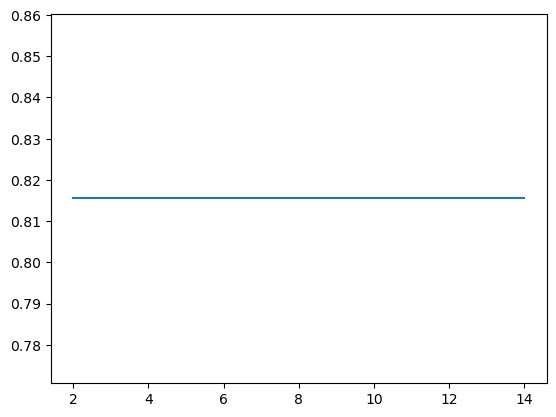

In [63]:
GRU_float = [0.8154915881472825, 0.8154915881472825, 0.8154915881472825, 0.8154915881472825, 0.8154915881472825, 0.8154915881472825, 0.8154915881472825]
plt.plot([2,4,6,8,10,12, 14], GRU_float, "-", label = "floating point")
plt.plot([2,4,6,8,10,12, 14], GRU_0int, "-o", label = '0 int')
# plt.plot([2,4,6,8,10,12, 14], GRU_1int, "-o", label = '1 int')
plt.plot([2,4,6,8,10,12, 14], GRU_2int, "-o", label = '2 int')
plt.plot([2,4,6,8,10,12, 14], GRU_4int, "-o", label = '4 int')
# plt.plot([1,2,4,6,8,10,12, ], AUC, "-o", label = '6 int')
# plt.plot([1,2,4,6,8,10,12], AUC8, "-o", label = '8 int')
# plt.plot([1,2,4,6,8,10,12], AUC10, "-o", label = '10 int')

plt.legend()
plt.xlabel("fractional bits")
plt.ylabel("AUC")
plt.title("QGRU QAT")
plt.grid()
plt.ylim([0.7, 0.82]) 

## QGRU weight

In [78]:
qgru = load_model('0int_qgru_test3/2frac_qgru_weights.h5', custom_objects={'QGRU': QGRU, 'QDense': QDense, 'quantized_bits': quantized_bits, 'QActivation': QActivation})
model_save_quantized_weights(qgru, f"ptq2int2fra_weight")

AttributeError: Exception encountered when calling layer "gru" (type QGRU).

in user code:

    File "/home/quin/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/qkeras/qrecurrent.py", line 1303, in call  *
        inputs, mask=mask, training=training, initial_state=initial_state)
    File "/home/quin/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/keras/src/layers/rnn/base_rnn.py", line 722, in call  **
        last_output, outputs, states = backend.rnn(
    File "/home/quin/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/keras/src/backend.py", line 4983, in rnn
        output_time_zero, _ = step_function(
    File "/home/quin/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/keras/src/layers/rnn/base_rnn.py", line 717, in step
        output, new_states = cell_call_fn(inputs, states, **kwargs)
    File "/home/quin/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_tra

## QLSTM

In [47]:


l1_reg = 0
l2_reg = 0

## GRU Model
#model = grumodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)

## LSTM Model
model = lstmmodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)
# new_LSTM_0int = []
# new_LSTM_1int = []
# new_LSTM_2int = []
# new_LSTM_4int = []
for int_bits in [0]:
    for i in [1]:
        total_bits = i + int_bits + 1
        config = {
            "QLSTM":{
                "kernel_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
                 "bias_quantizer" : f"quantized_bits({total_bits}, {int_bits},1)",
                 "recurrent_quantizer": f"quantized_bits({total_bits},{int_bits},1)",
                 "state_quantizer" : f"quantized_bits({total_bits},{int_bits},1)"
            },
            "QDense":{
                "kernel_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
                "bias_quantizer" : f"quantized_bits({total_bits},{int_bits},1)"
            },
            "relu_0" : f"quantized_relu({total_bits},{int_bits},1)",
            "relu_1" : f"quantized_relu({total_bits},{int_bits},1)",
        }
    
        qmodel = model_quantize(model, config, total_bits, transfer_weights=True)
    
# for layer in qmodel.layers:
#         if hasattr(layer, "recurrent_quantizer"):
#             print(layer.name, "kernel:", str(layer.kernel_quantizer_internal), "bias:", str(layer.bias_quantizer_internal), 
#                     "recurrent:", str(layer.recurrent_quantizer_internal), "state:", str(layer.state_quantizer_internal))
#         elif hasattr(layer, "kernel_quantizer"):
#             print(layer.name, "kernel:", str(layer.kernel_quantizer_internal), "bias:", str(layer.bias_quantizer_internal))
#         elif hasattr(layer, "quantized_relu"):
#             print(layer.name, "quantized_relu:", str(layer.quantizer))
#         else:
#             print(layer.name)
                
        qmodel.summary()
    
        qmodel.compile(optimizer='adam', loss=['categorical_crossentropy'], metrics=['accuracy'])
    
        model_output = f'{int_bits}int_qlstm_test3_notweight/{i}frac_qlstm_weights.h5'
    
        train = False
        if train:
            history = qmodel.fit(x_train, y_train,
                    batch_size=2**14,
                    epochs=100,
                    validation_data=(x_val, y_val),
                    shuffle = True,
                    sample_weight= w_train,
                    callbacks = [
                        EarlyStopping(verbose=True, patience=15, monitor='val_accuracy'),
                        ModelCheckpoint(model_output, monitor='val_accuracy', verbose=True, save_best_only=True)
                        ],
                    verbose=True
                    )
        #y_keras = qmodel.predict(x_test, batch_size=2**10)
        #auc_score = roc_auc_score(y_test, y_keras)
        #print("AUC score:", auc_score)
#         if int_bits == 1:
#             new_LSTM_1int.append(auc_score)
# #         elif int_bits == 0:
# #             new_LSTM_0int.append(auc_score)
# #         else:
# #             new_LSTM_4int.append(auc_score)

TypeError: Could not locate class 'QLSTM'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': 'keras.layers', 'class_name': 'QLSTM', 'config': {'name': 'lstm1', 'trainable': True, 'dtype': 'float32', 'return_sequences': False, 'return_state': False, 'go_backwards': False, 'stateful': False, 'unroll': False, 'time_major': False, 'units': 120, 'activation': 'quantized_tanh(2)', 'recurrent_activation': 'sigmoid', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'VarianceScaling', 'config': {'scale': 1.0, 'mode': 'fan_in', 'distribution': 'truncated_normal', 'seed': None}, 'registered_name': None}, 'recurrent_initializer': {'module': 'keras.initializers', 'class_name': 'Orthogonal', 'config': {'gain': 1.0, 'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'unit_forget_bias': Tr

In [ ]:
new_LSTM_0int = [0.5,
 0.759375387751892,
 0.7989484355227177,
 0.8030819593925612,
 0.8033667163742876,
 0.8027039533598156,
 0.8021881530344409,
 0.8025180589575464,
 0.8034173200659785,
 0.8019820586472483,
 0.8033968296080705]

In [ ]:
new_LSTM_1int = [0.7461276916152187,
 0.8004789138627902,
 0.8060313884130137,
 0.8066705966334711,
 0.8047598230808163,
 0.8063869565793077,
 0.8037114278686879,
 0.8057039744583717,
 0.8058117425449095,
 0.8050323066709777,
 0.8061466588554641]

In [ ]:
new_LSTM_2int = [0.795510871376552,
 0.8085795267629757,
 0.8079066913892133,
 0.8080574959094543,
 0.8072038114910124,
 0.8068566714570489,
 0.8066996444167445,
 0.8073183018132967,
 0.8078155800426238,
 0.8070635898235619]

In [ ]:
new_LSTM_4int = [0.8053497730620925,
 0.808071073300117,
 0.8066011183389149,
 0.8084180335188978,
 0.8082054539904887,
 0.8074122711848334,
 0.8085630838564253,
 0.8083730126609362,
 0.8073775819301302,
 0.8071676088396639]

In [ ]:
AUC_0int = [0.8019966937943156, 0.8056019505295176, 0.8043834232982888, 0.8035633347009626, 0.8042207873580036, 0.8038967592937954, 0.8061902536804495, 0.8047251266528449, 0.8064546998059575]

In [ ]:
AUC_2int = [0.8092423670870935, 0.805096025589327, 0.8058041858617452, 0.8051723112723406, 0.8069855747085065, 0.8056181357932739, 0.8075191545354666, 0.8066674305760979, 0.8096005409705623]

In [ ]:
AUC_4int = [0.8075657360375654, 0.8087467928467528, 0.8099972878505698, 0.8080579592351906, 0.8068300154461987, 0.8073075475855531, 0.8068326358740538, 0.8109530010286977, 0.8096943045219186]

(0.7, 0.82)

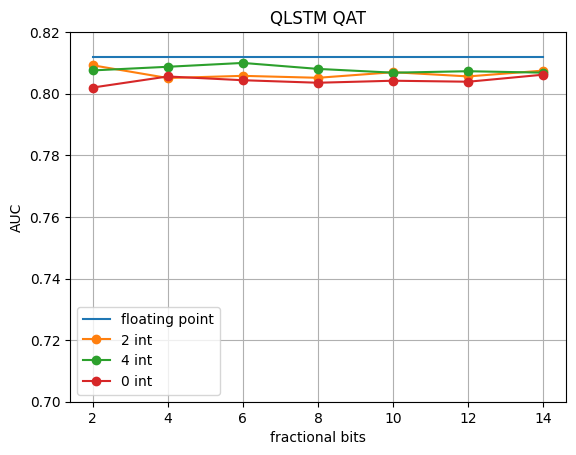

In [ ]:
float_lstm = [0.8118647593083379, 0.8118647593083379, 0.8118647593083379, 0.8118647593083379, 0.8118647593083379, 0.8118647593083379, 0.8118647593083379]
plt.plot([2,4,6,8,10,12, 14], float_lstm, "-", label = "floating point")
plt.plot([2,4,6,8,10,12, 14], AUC_2int, "-o", label = '2 int')
plt.plot([2,4,6,8,10,12, 14], AUC_4int, "-o", label = '4 int')
plt.plot([2,4,6,8,10,12, 14], AUC_0int, "-o", label = '0 int')
# plt.plot([1,2,4,6,8,10,12, ], AUC, "-o", label = '6 int')
# plt.plot([1,2,4,6,8,10,12], AUC8, "-o", label = '8 int')
# plt.plot([1,2,4,6,8,10,12], AUC10, "-o", label = '10 int')

plt.legend()
plt.xlabel("fractional bits")
plt.ylabel("AUC")
plt.title("QLSTM QAT")
plt.grid()
plt.ylim([0.7, 0.82]) 

(0.6, 1.05)

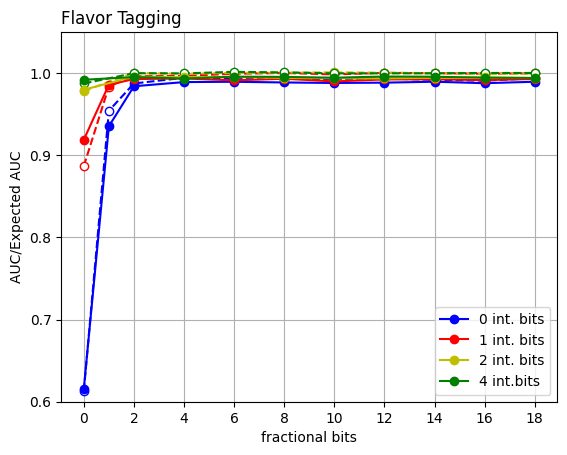

In [ ]:
GRU_float = 0.8154915881472825
LSTM_float = 0.8118647593083379
        

GRU_0int = np.array(new_GRU_0int)/GRU_float
GRU_1int = np.array(new_GRU_1int)/GRU_float
GRU_2int = np.array(new_GRU_2int)/GRU_float

GRU_4int = np.array(new_GRU_4int)/GRU_float


LSTM_0int = np.array(new_LSTM_0int)/LSTM_float
LSTM_1int = np.array(new_LSTM_1int)/LSTM_float
# print(new_LSTM_0int)
LSTM_2int = np.array(new_LSTM_2int)/LSTM_float

LSTM_4int = np.array(new_LSTM_4int)/LSTM_float

x = [0,2,4,6,8,10,12,14,16,18]
default_x_ticks = range(len(x))
plt.xticks(x, x)
plt.plot([0,1,2,4,6,8,10,12,14,16,18], GRU_0int, "bo--", markerfacecolor = 'white')
plt.plot([0,1,2,4,6,8,10,12,14,16,18], GRU_1int, "ro--", markerfacecolor = 'white')
plt.plot(x, GRU_2int, "yo--", markerfacecolor = 'white')
plt.plot(x, GRU_4int, "go--", markerfacecolor = 'white')
plt.plot([0,1,2,4,6,8,10,12,14,16,18], LSTM_0int, "bo-", label = '0 int. bits')
plt.plot([0,1,2,4,6,8,10,12,14,16,18], LSTM_1int, "ro-", label = '1 int. bits')
plt.plot(x, LSTM_2int, "yo-", label = '2 int. bits')
plt.plot(x, LSTM_4int, "go-", label = '4 int.bits')
plt.legend()
plt.xlabel("fractional bits")
plt.ylabel("AUC/Expected AUC")
plt.title("Flavor Tagging", loc='left')
plt.grid()
plt.ylim([0.6, 1.05]) 

In [ ]:
qmodel = load_model('0int_qlstm_test3_notweight/2frac_qlstm_weights.h5', custom_objects={'QLSTM': QLSTM, 'QDense': QDense, 'quantized_bits': quantized_bits, 'QActivation': QActivation})
model_save_quantized_weights(qmodel, f"qat2int2fra_weight")

... quantizing model


{'lstm1': {'weights': [array([[-0.5 ,  0.  ,  0.5 , ...,  0.75,  0.25,  0.25],
          [-0.25, -0.25, -0.25, ..., -0.25,  0.25, -0.75],
          [ 0.  ,  0.  ,  0.75, ..., -0.25,  0.  ,  0.  ],
          [-0.5 ,  0.25,  0.75, ...,  0.25,  0.25,  0.25],
          [ 0.  , -0.5 ,  0.25, ...,  0.  , -0.75,  0.25],
          [ 0.25, -0.5 ,  0.  , ..., -0.25, -0.5 , -0.25]], dtype=float32),
   array([[-0.25 ,  0.125,  0.   , ...,  0.25 ,  0.   ,  0.   ],
          [-0.25 , -0.125,  0.   , ...,  0.   , -0.125, -0.125],
          [ 0.5  ,  0.125,  0.25 , ...,  0.25 ,  0.   ,  0.25 ],
          ...,
          [ 0.   ,  0.125,  0.   , ...,  0.   ,  0.   ,  0.   ],
          [ 0.   , -0.125,  0.   , ...,  0.25 ,  0.   ,  0.   ],
          [ 0.   , -0.125,  0.   , ...,  0.25 ,  0.   , -0.25 ]],
         dtype=float32),
   array([ 0.25,  0.  ,  0.5 , -0.25,  0.5 ,  0.  ,  0.25,  0.5 ,  0.  ,
           0.5 ,  0.  ,  0.  ,  0.25,  0.5 ,  0.25,  0.5 ,  0.  ,  0.  ,
           0.  ,  0.25,  0.25,  

## Post Training Quantization

## QLSTM

In [15]:
lstm = load_model('lstm_test2/lstm_weights.h5') #model_lstm_weights.h5

OSError: Unable to open file (file signature not found)

In [ ]:
# PTQ2int = []
# PTQ4int = []
PTQ1int = []
PTQ0int = []
from qkeras.utils import model_quantize
from qkeras.utils import model_save_quantized_weights
for i in [0, 1]:
    for j in [2, 4, 6, 8, 10, 12, 14]:
        int_bits = i
        total_bits = i+j+1
        config = {
            "QLSTM":{
                "kernel_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
                 "bias_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
                 "recurrent_quantizer": f"quantized_bits({total_bits},{int_bits},1)",
                 "state_quantizer" : f"quantized_bits({total_bits},{int_bits},1)"
            },
            "QDense":{
                "kernel_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
                "bias_quantizer" : f"quantized_bits({total_bits},{int_bits},1)"
            },
            "relu_0" : f"quantized_relu({total_bits},{int_bits},1)",
            "relu_1" : f"quantized_relu({total_bits},{int_bits},1)",
        }
        qmodel = model_quantize(lstm, config, total_bits, transfer_weights=True)

#         qmodel.summary()

        for layer in qmodel.layers:
            if hasattr(layer, "recurrent_quantizer"):
                print(layer.name, "kernel:", str(layer.kernel_quantizer_internal), "bias:", str(layer.bias_quantizer_internal), 
                     "recurrent:", str(layer.recurrent_quantizer_internal), "state:", str(layer.state_quantizer_internal))
            elif hasattr(layer, "kernel_quantizer"):
                print(layer.name, "kernel:", str(layer.kernel_quantizer_internal), "bias:", str(layer.bias_quantizer_internal))
            elif hasattr(layer, "quantized_relu"):
                print(layer.name, "quantized_relu:", str(layer.quantizer))
            else:
                print(layer.name)
                
        model_save_quantized_weights(qmodel, f"ptq{i}int{j}fra_weight")
        y_keras = qmodel.predict(x_test, batch_size=2**10)
        auc_score = roc_auc_score(y_test, y_keras)
        print("AUC score:", auc_score)
        if i == 0:
            PTQ0int.append(auc_score)
        else:
            PTQ1int.append(auc_score)

NameError: name 'lstm' is not defined

In [ ]:
PTQ_2int = [0.7138402385262174, 0.7697426759545337, 0.795030969988355, 0.7959740415614672, 0.7965695165044027, 0.7965597107777665, 0.796992236571457]

In [ ]:
PTQ_4int = [0.7204539145373472, 0.7788773707089733, 0.7948387248147831, 0.7965026440227403, 0.7993372082142057, 0.7999884160098358, 0.8001326665853764]

In [ ]:
print(PTQ2int)

[0.7697456491241724, 0.7950334429664642, 0.7962076821540339, 0.7965694400474576, 0.7965596510581459, 0.7969792420735934, 0.7971674337337867]


In [ ]:
print(PTQ4int)

[0.778671831721396, 0.7946760751838718, 0.7966748955925538, 0.7977211569496075, 0.7976043675022462, 0.7993241590003554, 0.7999746037087557]


(0.7, 0.82)

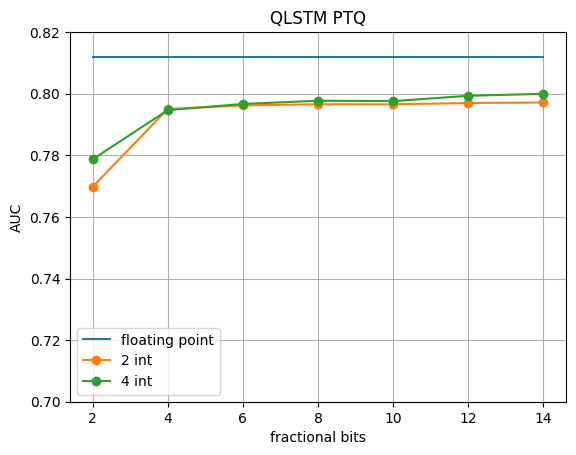

In [ ]:
float_lstm = [0.8118647593083379, 0.8118647593083379, 0.8118647593083379, 0.8118647593083379, 0.8118647593083379, 0.8118647593083379, 0.8118647593083379]
plt.plot([2,4,6,8,10,12,14], float_lstm, "-", label = "floating point")
plt.plot([2,4,6,8,10,12,14], PTQ2int, "-o", label = '2 int')
plt.plot([2,4,6,8,10,12,14], PTQ4int, "-o", label = '4 int')
# plt.plot([1,2,4,6,8,10,12, ], AUC, "-o", label = '6 int')
# plt.plot([1,2,4,6,8,10,12], AUC8, "-o", label = '8 int')
# plt.plot([1,2,4,6,8,10,12], AUC10, "-o", label = '10 int')

plt.legend()
plt.xlabel("fractional bits")
plt.ylabel("AUC")
plt.title("QLSTM PTQ")
plt.grid()
plt.ylim([0.7, 0.82]) 

## QGRU

In [11]:
gru = load_model('gru_test3/gru_weights.h5')

OSError: Unable to open file (file signature not found)

In [ ]:
PTQ2intgru = []
PTQ4intgru = []
from qkeras.utils import model_quantize
from qkeras.utils import model_save_quantized_weights
for i in [2, 4]:
    for j in [2, 4, 6, 8, 10, 12, 14]:
        int_bits = i
        total_bits = i+j+1
        config = {
            "QGRU":{
                "kernel_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
                 "bias_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
                 "recurrent_quantizer": f"quantized_bits({total_bits},{int_bits},1)",
                 "state_quantizer" : f"quantized_bits({total_bits},{int_bits},1)"
            },
            "QDense":{
                "kernel_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
                "bias_quantizer" : f"quantized_bits({total_bits},{int_bits},1)"
            },
            "relu_0" : f"quantized_relu({total_bits},{int_bits},1)",
            "relu_1" : f"quantized_relu({total_bits},{int_bits},1)",
        }
        qmodel = model_quantize(gru, config, total_bits, transfer_weights=True)

#         qmodel.summary()

        for layer in qmodel.layers:
            if hasattr(layer, "recurrent_quantizer"):
                print(layer.name, "kernel:", str(layer.kernel_quantizer_internal), "bias:", str(layer.bias_quantizer_internal), 
                     "recurrent:", str(layer.recurrent_quantizer_internal), "state:", str(layer.state_quantizer_internal))
            elif hasattr(layer, "kernel_quantizer"):
                print(layer.name, "kernel:", str(layer.kernel_quantizer_internal), "bias:", str(layer.bias_quantizer_internal))
            elif hasattr(layer, "quantized_relu"):
                print(layer.name, "quantized_relu:", str(layer.quantizer))
            else:
                print(layer.name)
                
#         model_save_quantized_weights(qmodel, f"ptq{i}int{j}fra_weight")
        y_keras = qmodel.predict(x_test, batch_size=2**10)
        auc_score = roc_auc_score(y_test, y_keras)
        print("AUC score:", auc_score)
        if i == 2:
            PTQ2intgru.append(auc_score)
        else:
            PTQ4intgru.append(auc_score)

input_1
gru kernel: quantized_bits(5,2,1,alpha='auto_po2') bias: quantized_bits(5,2,1) recurrent: quantized_bits(5,2,1,alpha='auto_po2') state: quantized_bits(5,2,1)
dense_0 kernel: quantized_bits(5,2,1,alpha='auto_po2') bias: quantized_bits(5,2,1)
relu_0
dense_1 kernel: quantized_bits(5,2,1,alpha='auto_po2') bias: quantized_bits(5,2,1)
relu_1
dense_2 kernel: quantized_bits(5,2,1,alpha='auto_po2') bias: quantized_bits(5,2,1)
output_softmax
294/294 [==============================] - 15s 47ms/step
AUC score: 0.756710119543415
input_1
gru kernel: quantized_bits(7,2,1,alpha='auto_po2') bias: quantized_bits(7,2,1) recurrent: quantized_bits(7,2,1,alpha='auto_po2') state: quantized_bits(7,2,1)
dense_0 kernel: quantized_bits(7,2,1,alpha='auto_po2') bias: quantized_bits(7,2,1)
relu_0
dense_1 kernel: quantized_bits(7,2,1,alpha='auto_po2') bias: quantized_bits(7,2,1)
relu_1
dense_2 kernel: quantized_bits(7,2,1,alpha='auto_po2') bias: quantized_bits(7,2,1)
output_softmax
294/294 [=================

(0.7, 0.82)

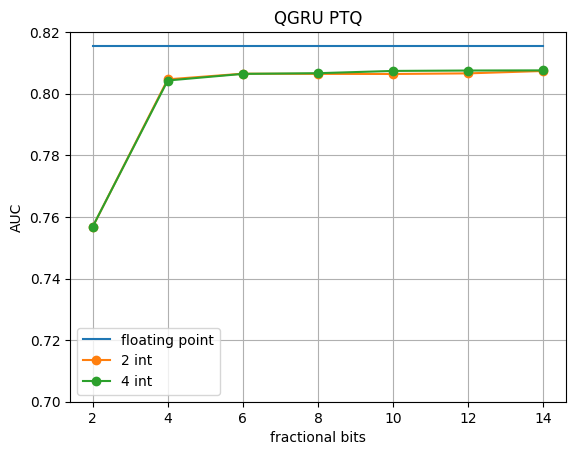

In [ ]:
GRU_float = [0.8154915881472825, 0.8154915881472825, 0.8154915881472825, 0.8154915881472825, 0.8154915881472825, 0.8154915881472825, 0.8154915881472825]
plt.plot([2,4,6,8,10,12,14], GRU_float, "-", label = "floating point")
plt.plot([2,4,6,8,10,12,14], PTQ2intgru, "-o", label = '2 int')
plt.plot([2,4,6,8,10,12,14], PTQ4intgru, "-o", label = '4 int')
# plt.plot([1,2,4,6,8,10,12, ], AUC, "-o", label = '6 int')
# plt.plot([1,2,4,6,8,10,12], AUC8, "-o", label = '8 int')
# plt.plot([1,2,4,6,8,10,12], AUC10, "-o", label = '10 int')

plt.legend()
plt.xlabel("fractional bits")
plt.ylabel("AUC")
plt.title("QGRU PTQ")
plt.grid()
plt.ylim([0.7, 0.82])

## Check AUC detail 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pandas as pd
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False, 
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    #plt.title(title)
    cbar = plt.colorbar()
    plt.clim(0,1)
    cbar.set_label(title)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    #plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

def plotRoc(y, predict_test, linestyle, legend=True):
    
    labels = ['b vs l (pb/pl)', 'b vs c (pb/pc)']
    
    pb_b = predict_test[:,0] [y[:,0] == 1]
    pc_b = predict_test[:,1] [y[:,0] == 1]
    pl_b = predict_test[:,2] [y[:,0] == 1]
    
    pc_c = predict_test[:,1] [y[:,1] == 1]
    pb_c = predict_test[:,0] [y[:,1] == 1]
    
    pl_l = predict_test[:,2] [y[:,2] == 1]
    pb_l = predict_test[:,0] [y[:,2] == 1]
    
    hist_b_bvl = np.histogram( pb_b/(pb_b+pl_b), range=(0,1), bins=100000 )
    hist_l_bvl = np.histogram( pb_l/(pb_l+pl_l), range=(0,1), bins=100000 )

    hist_b_bvc = np.histogram( pb_b/(pb_b+pc_b), range=(0,1), bins=100000 )
    hist_c_bvc = np.histogram( pb_c/(pb_c+pc_c), range=(0,1), bins=100000 )

    hist_b_bvl_eff = hist_b_bvl[0][::-1].cumsum()[::-1]/hist_b_bvl[0].sum()
    hist_l_bvl_eff = hist_l_bvl[0][::-1].cumsum()[::-1]/hist_l_bvl[0].sum()
    
    hist_b_bvc_eff = hist_b_bvc[0][::-1].cumsum()[::-1]/hist_b_bvc[0].sum()
    hist_c_bvc_eff = hist_c_bvc[0][::-1].cumsum()[::-1]/hist_c_bvc[0].sum()
    
    auc_bvl = auc(hist_l_bvl_eff, hist_b_bvl_eff)
    auc_bvc = auc(hist_c_bvc_eff, hist_b_bvc_eff)
    
    plt.plot( hist_b_bvl_eff, hist_l_bvl_eff, label=f'b vs l (pb/pl), AUC = {auc_bvl:.2f}', linestyle=linestyle )
    plt.plot( hist_b_bvc_eff, hist_c_bvc_eff, label=f'b vs c (pb/pc), AUC = {auc_bvc:.2f}', linestyle=linestyle )
    
    plt.semilogy()
    plt.xlabel("b-Jet Efficiency")
    plt.ylabel("Background Efficiency")
    plt.ylim(0.001,1)
    plt.grid(True)
    if legend: plt.legend(loc='upper left')
    plt.figtext(0.25, 0.90,'hls4ml',fontweight='bold', wrap=True, horizontalalignment='right', fontsize=14)

def rocData(y, predict_test):
    
    labels = ['b vs l (pb/pl)', 'b vs c (pb/pc)']
    
    pb_b = predict_test[:,0] [y[:,0] == 1]
    pc_b = predict_test[:,1] [y[:,0] == 1]
    pl_b = predict_test[:,2] [y[:,0] == 1]
    
    pc_c = predict_test[:,1] [y[:,1] == 1]
    pb_c = predict_test[:,0] [y[:,1] == 1]
    
    pl_l = predict_test[:,2] [y[:,2] == 1]
    pb_l = predict_test[:,0] [y[:,2] == 1]
    
    
    hist_b_bvl = np.histogram( pb_b/(pb_b+pl_b), range=(0,1), bins=1000 )
    hist_l_bvl = np.histogram( pb_l/(pb_l+pl_l), range=(0,1), bins=1000 )

    hist_b_cvl = np.histogram( pb_b/(pb_b+pc_b), range=(0,1), bins=1000 )
    hist_c_cvl = np.histogram( pb_c/(pb_c+pc_c), range=(0,1), bins=1000 )

    hist_b_bvl_eff = hist_b_bvl.cumsum()/hist_b_bvl.sum()
    hist_l_bvl_eff = hist_l_bvl.cumsum()/hist_l_bvl.sum()
    
    hist_b_cvl_eff = hist_b_cvl.cumsum()/hist_b_cvl.sum()
    hist_c_cvl_eff = hist_c_cvl.cumsum()/hist_c_cvl.sum()

    df = pd.DataFrame()

    fpr = {}
    tpr = {}
    auc1 = {}

    for i, label in enumerate(labels):
        df[label] = y[:,i]
        df[label + '_pred'] = predict_test[:,i]

        fpr[label], tpr[label], threshold = roc_curve(df[label],df[label+'_pred'])

        auc1[label] = auc(fpr[label], tpr[label])
    return effs, auc1

def makeRoc(y, predict_test, linestyle='-', legend=True):
      
    plotRoc(y, predict_test, linestyle, legend)
    
#     effs, auc1 = rocData(y, predict_test, labels)
#     plotRoc(fpr, tpr, auc1, labels, linestyle, legend=legend)
#     return predict_test

def print_dict(d, indent=0):
    align=20
    for key, value in d.items():
        print('  ' * indent + str(key), end='')
        if isinstance(value, dict):
            print()
            print_dict(value, indent+1)
        else:
            print(':' + ' ' * (20 - len(key) - 2 * indent) + str(value))

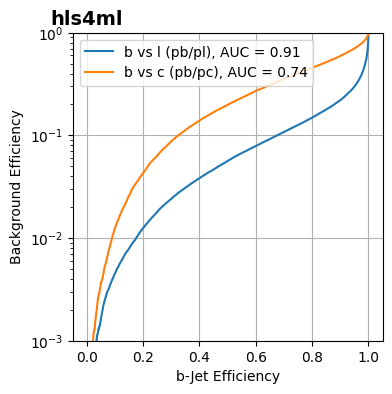

In [ ]:
plt.figure(figsize=(4,4))
_ = makeRoc(y_test, y_keras)

In [77]:
#from tensorflow.keras.models import load_model
#from tensorflow.keras.models import load_weights

model.load_weights('2int_qgru_test3/2frac_qgru_weights.h5')
#model.load_weights(filepath = '2int_qgru_test3/2frac_qgru_weights.h5')

#model = load_weights('2int_qgru_test3/2frac_qgru_weights.h5')
#model = load_model('2int_qgru_test3/2frac_qgru_weights.h5')

In [45]:
config['LayerName']['fc1']['Precision']['weight'] = 'ap_fixed<8,2>'
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, output_dir='model_1/hls4ml_prj_2', part='xcu250-figd2104-2L-e'
)
numerical(model=model, hls_model=hls_model)
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

KeyError: 'LayerName'